<a href="https://colab.research.google.com/github/shaipshiverya/Data_Analysis_python_projects/blob/main/v3Global_Inequality_Poverty_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌍 Global Economic Inequality & Poverty Analysis (1980–2024)
## A Macroeconomic Analytics Project

**Domain:** Economics / Global Development  
**Dataset:** Global Economic Inequality and Poverty Dataset — ~200 countries, 1980–2024  
**Source:** Combines data from Our World in Data, World Bank, and the World Inequality Database (WID)

---

### 🎯 Business Problem
Understanding how income and wealth are distributed across the world — and how that distribution has evolved — is essential for policymakers, international development organizations, and economic researchers. Persistent inequality and poverty shape decisions around aid allocation, trade policy, and social programs.

This project analyzes country-year level economic data to answer: **how has global inequality and poverty evolved since 1980, how concentrated is income at the top vs the bottom of the distribution, and how does economic development (GDP per capita) relate to inequality?**

**End Users:** Economic policy analysts & international development researchers

### 📋 Project Workflow
1. Data Loading & Understanding
2. Data Cleaning & Coverage Assessment
3. Exploratory Data Analysis — Inequality Trends, Income Distribution, GDP Relationship, Poverty Trends
4. Key Findings & Recommendations

---


## 📦 Section 1: Setup — Import Libraries & Load Data


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Consistent color palette used across all charts
palette_main = 'steelblue'
palette_trend = 'darkred'
palette_top10 = 'crimson'
palette_bottom50 = 'seagreen'
palette_scatter = 'teal'
palette_poverty = 'darkorange'


### Load the dataset


In [2]:
df = pd.read_csv('disuguaglianza-economica-globale-e-povert-1980-2024.csv')

print('Dataset shape:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())
df.head()


Dataset shape: (8955, 11)

Column names:
['country', 'year', 'iso_code', 'population', 'gdp', 'gdp_per_capita', 'poverty_rate', 'gini_index', 'income_top1', 'income_top10', 'income_bottom50']


,country,year,iso_code,population,gdp,gdp_per_capita,poverty_rate,gini_index,income_top1,income_top10,income_bottom50
0,Afghanistan,1980,AFG,13169313,1.532984e+10,1164.06,NaN,NaN,16.22,41.94,17.17
1,Afghanistan,1981,AFG,11937586,1.564534e+10,1310.60,NaN,NaN,16.22,41.94,17.17
2,Afghanistan,1982,AFG,10991380,1.598041e+10,1453.90,NaN,NaN,16.22,41.94,17.17
3,Afghanistan,1983,AFG,10917985,1.675533e+10,1534.65,NaN,NaN,16.22,41.94,17.17
4,Afghanistan,1984,AFG,11190222,1.707215e+10,1525.63,NaN,NaN,16.22,41.94,17.17


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8955 entries, 0 to 8954
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          8955 non-null   object 
 1   year             8955 non-null   int64  
 2   iso_code         8955 non-null   object 
 3   population       8955 non-null   int64  
 4   gdp              7035 non-null   float64
 5   gdp_per_capita   7035 non-null   float64
 6   poverty_rate     2207 non-null   float64
 7   gini_index       2207 non-null   float64
 8   income_top1      8280 non-null   float64
 9   income_top10     8280 non-null   float64
 10  income_bottom50  8280 non-null   float64
dtypes: float64(7), int64(2), object(2)
memory usage: 769.7+ KB


## 🧹 Section 2: Data Cleaning & Coverage Assessment

Global economic datasets are rarely complete — many indicators rely on household surveys that aren't conducted every year in every country. Before analyzing trends, it's important to understand **how much data is actually available** for each variable.


In [4]:
# Check missing values per column
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_summary


,Missing Count,Missing %
poverty_rate,6748,75.4
gini_index,6748,75.4
gdp_per_capita,1920,21.4
gdp,1920,21.4
income_top10,675,7.5
income_bottom50,675,7.5
income_top1,675,7.5
iso_code,0,0.0
year,0,0.0
country,0,0.0


### 2.1 — Missing Values by Variable


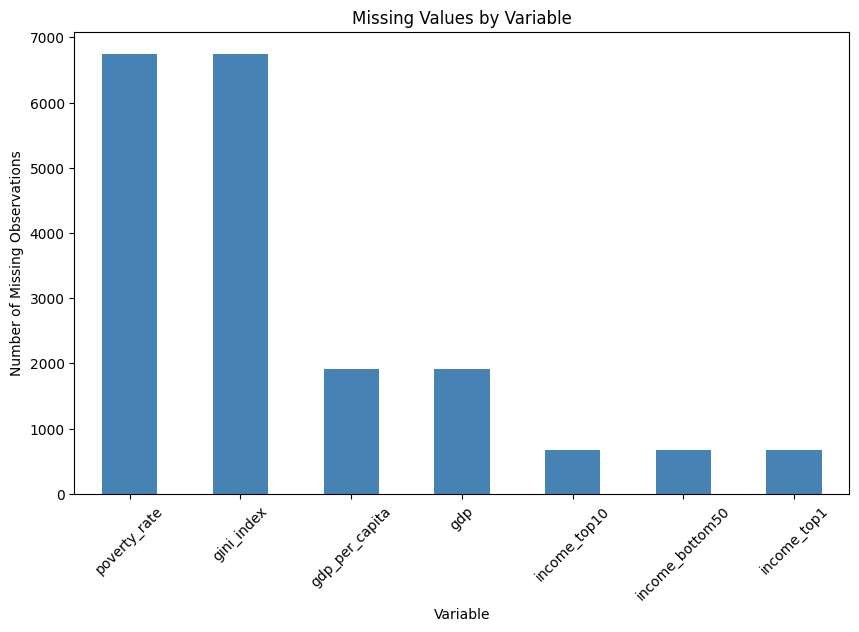

In [5]:
plt.figure(figsize=(10,6))

missing[missing > 0].plot(kind='bar', color=palette_main)

plt.title('Missing Values by Variable')
plt.xlabel('Variable')
plt.ylabel('Number of Missing Observations')
plt.xticks(rotation=45)

plt.show()


**💡 Insight:** `poverty_rate` and `gini_index` have the highest number of missing values — both are survey-based indicators that aren't collected annually in every country. Income distribution columns (`income_top1`, `income_top10`, `income_bottom50`) have comparatively better coverage. This means trend analysis on Gini and poverty should focus on years with stronger data availability, rather than the full 1980–2024 range.


In [6]:
# Years with stronger Gini and poverty coverage
coverage_by_year = df.groupby('year')[['gini_index','poverty_rate']].apply(lambda x: x.notna().sum())
coverage_by_year.tail(15)


,gini_index,poverty_rate
year,,
2010,83,83
2011,79,79
2012,85,85
2013,76,76
2014,82,82
2015,85,85
2016,82,82
2017,78,78
2018,93,93


**💡 Insight:** Data coverage for Gini and poverty improves significantly from around 2015 onward, when more countries began reporting consistent survey-based estimates. For this reason, the inequality and poverty trend analysis in this notebook focuses on **2015–2023** (2024 has very limited reporting so far), which gives a more representative global picture.


## 📊 Section 3: Exploratory Data Analysis (EDA)


### 3.1 — Global Inequality Trend (Gini Index, 2015–2023)


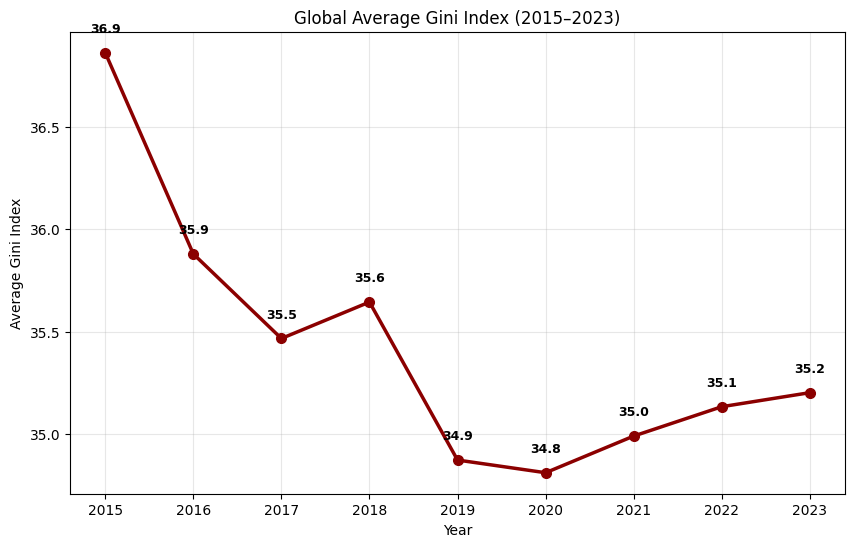

In [7]:
gini_recent = df[(df['year'] >= 2015) & (df['year'] <= 2023)].dropna(subset=['gini_index'])
gini_trend = gini_recent.groupby('year')['gini_index'].mean()

plt.figure(figsize=(10,6))

ax = gini_trend.plot(kind='line', color=palette_trend, marker='o', linewidth=2.5, markersize=7)

plt.title('Global Average Gini Index (2015–2023)')
plt.xlabel('Year')
plt.ylabel('Average Gini Index')
plt.grid(alpha=0.3)

for x, y in zip(gini_trend.index, gini_trend.values):
    ax.text(x, y + 0.1, f'{y:.1f}', ha='center', fontsize=9, fontweight='bold')

plt.show()


**💡 Insight:** The global average Gini index has stayed relatively stable between roughly 35 and 36 points over this period, with only minor year-to-year fluctuation. This suggests that, on average, income inequality at the global level hasn't shifted dramatically in the last decade — though country-level patterns can vary widely beneath this average.


### 3.2 — Income Concentration: Top 10% vs Bottom 50%


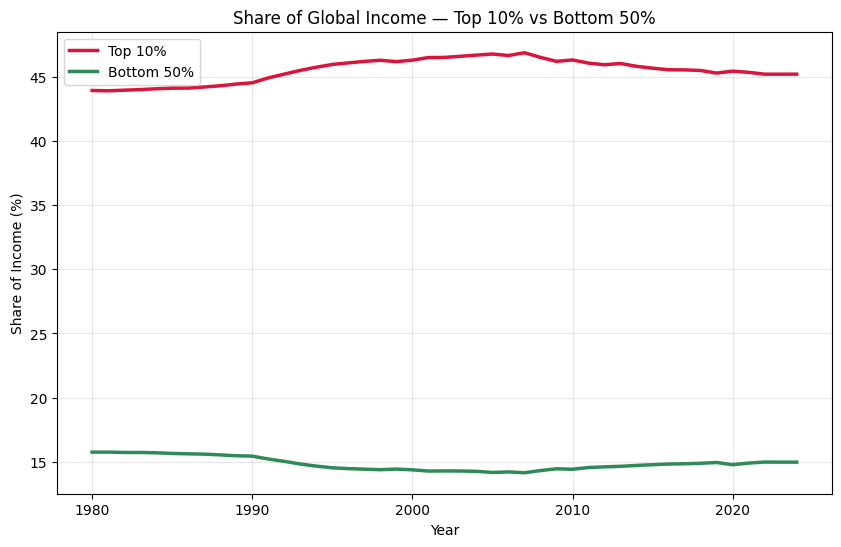

In [8]:
top10_trend = df.groupby('year')['income_top10'].mean()
bottom50_trend = df.groupby('year')['income_bottom50'].mean()

plt.figure(figsize=(10,6))

top10_trend.plot(kind='line', color=palette_top10, linewidth=2.5, label='Top 10%')
bottom50_trend.plot(kind='line', color=palette_bottom50, linewidth=2.5, label='Bottom 50%')

plt.title('Share of Global Income — Top 10% vs Bottom 50%')
plt.xlabel('Year')
plt.ylabel('Share of Income (%)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()


**💡 Insight:** The richest 10% of the population consistently holds around 45–47% of global income, while the poorest 50% holds only about 14–16%. In other words, the bottom half of the world's population earns less than a third of what the top 10% earns. This gap has remained remarkably stable across the dataset's timeframe, indicating persistent — not worsening or improving — structural inequality.


### 3.3 — GDP per Capita vs Inequality


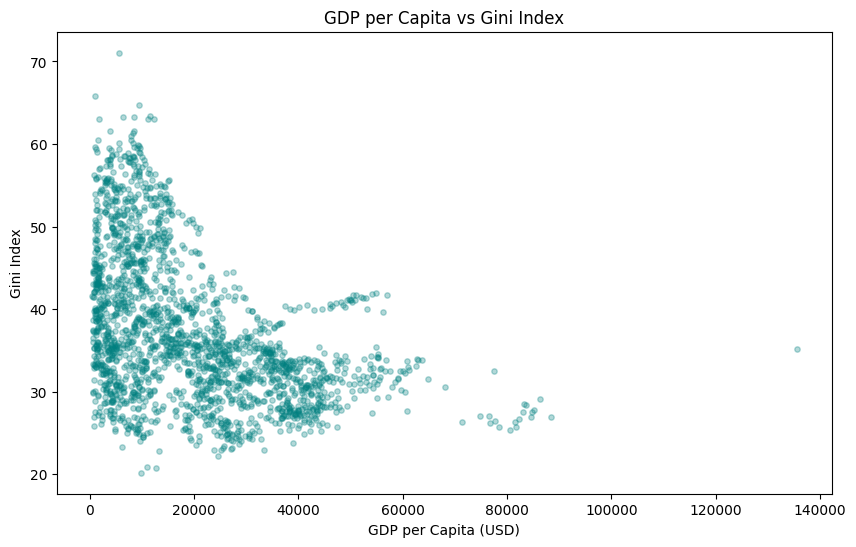

In [9]:
plt.figure(figsize=(10,6))

plt.scatter(df['gdp_per_capita'], df['gini_index'], alpha=0.3, color=palette_scatter, s=15)

plt.title('GDP per Capita vs Gini Index')
plt.xlabel('GDP per Capita (USD)')
plt.ylabel('Gini Index')

plt.show()


**💡 Insight:** Lower-income countries show highly variable Gini scores — some are relatively equal, others highly unequal. Higher-income countries tend to cluster at more moderate Gini values, suggesting a loose association between economic development and lower inequality. However, the relationship is far from linear — institutional, political, and social factors clearly play a major role beyond GDP alone.


### 3.4 — Global Poverty Rate Trend (2015–2023)


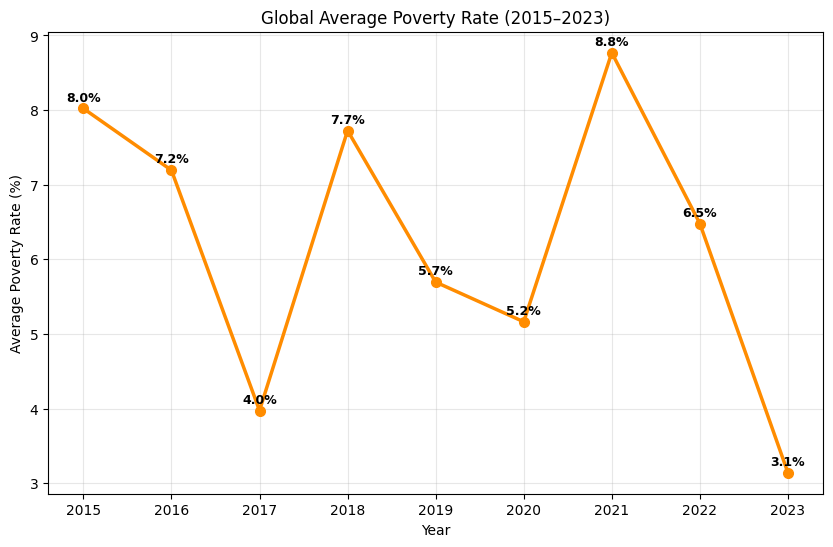

In [10]:
poverty_recent = df[(df['year'] >= 2015) & (df['year'] <= 2023)].dropna(subset=['poverty_rate'])
poverty_trend = poverty_recent.groupby('year')['poverty_rate'].mean()

plt.figure(figsize=(10,6))

ax = poverty_trend.plot(kind='line', color=palette_poverty, marker='o', linewidth=2.5, markersize=7)

plt.title('Global Average Poverty Rate (2015–2023)')
plt.xlabel('Year')
plt.ylabel('Average Poverty Rate (%)')
plt.grid(alpha=0.3)

for x, y in zip(poverty_trend.index, poverty_trend.values):
    ax.text(x, y + 0.1, f'{y:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.show()


**💡 Insight:** The global average poverty rate started near 8% in 2015 and has shown a generally stable-to-declining pattern with some year-to-year variation through 2023. As with the other indicators, this average only reflects countries with available data, so it should be read as a directional trend rather than a precise global measurement.


### 3.5 — Top 10 Most Unequal Countries (Latest Available Gini)


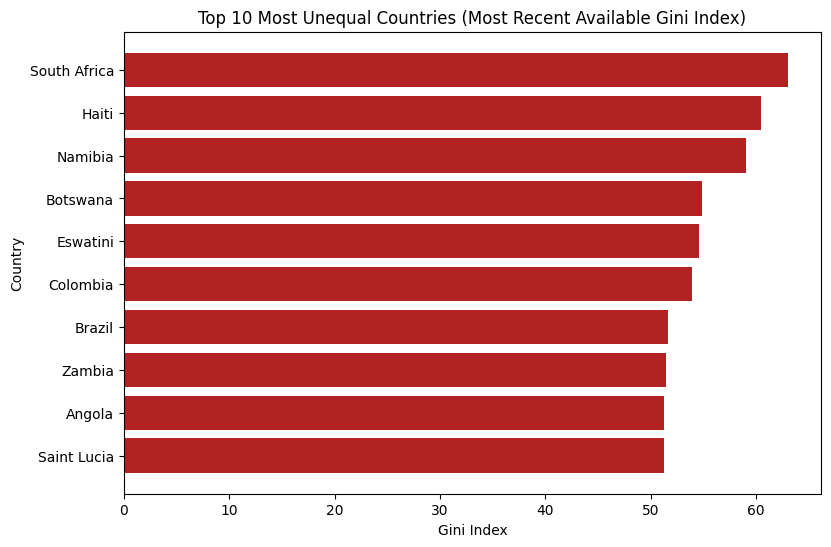

In [11]:
latest_gini = df.dropna(subset=['gini_index']).sort_values('year').groupby('country').tail(1)
top_unequal = latest_gini.sort_values('gini_index', ascending=False).head(10)[['country','year','gini_index']]

plt.figure(figsize=(9,6))

plt.barh(top_unequal['country'][::-1], top_unequal['gini_index'][::-1], color='firebrick')

plt.title('Top 10 Most Unequal Countries (Most Recent Available Gini Index)')
plt.xlabel('Gini Index')
plt.ylabel('Country')

plt.show()


**💡 Insight:** The countries with the highest Gini index, based on their most recent available reading, are concentrated mostly in regions with well-documented structural inequality. This view complements the global average — while the world average is stable, individual countries can sit far above or below that average, which matters for country-specific policy design.


## ✅ Section 4: Key Findings & Recommendations

### 🔬 Key Findings
1. **Global inequality (Gini index) has remained largely stable** between 2015–2023, hovering around 35–36 points on average
2. **Income concentration is persistent and significant** — the top 10% consistently holds 45–47% of global income, while the bottom 50% holds only 14–16%
3. **GDP per capita and inequality show a loose negative association** — wealthier countries tend toward moderate Gini scores, but the relationship is far from linear
4. **Global poverty rate has shown a broadly stable-to-declining trend** since 2015, though year-to-year variation exists
5. **Data coverage is uneven** — Gini and poverty indicators rely heavily on household surveys, which aren't conducted annually in every country, especially before 2015

---

### 💼 Recommendations

**1. Focus Policy Analysis on Post-2015 Data**  
Given the significant jump in data coverage from 2015 onward, any inequality or poverty trend analysis should prioritize this period for the most statistically reliable conclusions.

**2. Prioritize Bottom-50% Income Growth, Not Just GDP Growth**  
Since GDP per capita only loosely correlates with lower inequality, policies aimed purely at GDP growth may not meaningfully reduce income concentration. Targeted redistribution or wage-floor policies may be more directly effective.

**3. Investigate High-Gini Countries Individually**  
The countries with persistently high Gini scores warrant case-by-case investigation into institutional and policy drivers, rather than being grouped into the stable global average.

**4. Improve Survey Data Collection in Underrepresented Countries**  
Many countries lack consistent Gini and poverty reporting. Supporting more frequent household income surveys, especially in lower-income regions, would improve the reliability of future global inequality estimates.

**5. Monitor Income Share Trends, Not Just Gini**  
Since the Gini index can mask underlying shifts, tracking top 10% vs bottom 50% income shares directly (as done in this analysis) gives a clearer, more interpretable picture of where inequality is concentrated.

---

> **Bottom line:** Global income inequality has remained structurally persistent over the past decade — not worsening dramatically, but not improving either. The gap between the top 10% and bottom 50% remains wide and stable, and meaningful change is likely to require targeted distributional policy rather than economic growth alone.

---

### ⚠️ Limitations
- Gini and poverty indicators are not available for all countries and all years
- Data primarily comes from household income/consumption surveys, which are not conducted annually everywhere
- Global averages are calculated only from countries with available data, so they may not represent the entire world population
- For some countries, income distribution estimates remain constant across multiple years, reflecting limited new survey data rather than true stability

---
*Tools: Python, pandas, matplotlib, seaborn | Domain: Economics / Global Development*
